In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import Dataset, DataLoader
import torch
print(torch.__version__)
print(torch.cuda.is_available())      # 应该是 True
print(torch.cuda.get_device_name(0))  # 应该显示 RTX 5060

2.10.0+cu128
True
NVIDIA GeForce RTX 5070 Laptop GPU


In [2]:
CSV_PATH=r"C:\Users\xhu70\Projects\twel_data_collection\data\sensor_data.csv"
WINDOW_SIZE=450
PREDICTION_AHEAD=450
TARGET_COL="temperature_c"
BATCH_SIZE=64
HIDDEN_SIZE=64
NUM_LAYERS=2
EPOCHS=20
LR=0.001

In [3]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
df=pd.read_csv(CSV_PATH,parse_dates=["timestamp"])
df=df.sort_values("timestamp").reset_index(drop=True)
#df = df[df["temperature_c"] <= ].reset_index(drop=True)


In [5]:
print(f"数据总行数: {len(df)}")
print(f"时间范围: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"缺失值:\n{df.isnull().sum()}\n")

数据总行数: 59359
时间范围: 2026-03-07 18:12:00 → 2026-03-15 12:21:36
缺失值:
timestamp        0
temperature_c    0
humidity_pct     0
pressure_hpa     0
dtype: int64



In [6]:
FEATURES=["temperature_c", "humidity_pct", "pressure_hpa"]
data=df[FEATURES].values

In [7]:
scaler=MinMaxScaler()
target_index=FEATURES.index(TARGET_COL)
split_idx = int(len(data) * 0.6)
scaler = MinMaxScaler()
data_scaled = data.copy()
data_scaled[:split_idx] = scaler.fit_transform(data[:split_idx])
data_scaled[split_idx:] = scaler.transform(data[split_idx:])

target_min = scaler.data_min_[target_index]
target_max = scaler.data_max_[target_index]

In [8]:
def create_sequences(data, window_size, target_col_index,prediction_ahead):    # 创建滑动窗口
    total = len(data) - window_size - prediction_ahead
    X = np.zeros((total, window_size, data.shape[1]), dtype=np.float32)
    y = np.zeros(total, dtype=np.float32)
    for i in range(total):
        X[i] = data[i : i + window_size]
        y[i] = data[i + window_size + prediction_ahead, target_col_index]
    return X, y

In [9]:
X,y=create_sequences(data_scaled, WINDOW_SIZE, target_index, PREDICTION_AHEAD)

In [10]:

split_train = int(len(X) * 0.6)
split_val   = int(len(X) * 0.8)

X_train, y_train = X[:split_train],          y[:split_train]
X_val,   y_val   = X[split_train:split_val], y[split_train:split_val]
X_test,  y_test  = X[split_val:],            y[split_val:]

In [11]:
X_train=torch.FloatTensor(X_train)
X_test=torch.FloatTensor(X_test)
y_train=torch.FloatTensor(y_train).unsqueeze(1)
y_test=torch.FloatTensor(y_test).unsqueeze(1)
X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val).unsqueeze(1)

In [12]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [13]:
train_loader = DataLoader(TimeSeriesDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TimeSeriesDataset(X_test, y_test),
                          batch_size=BATCH_SIZE, shuffle=False)

In [14]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
        super().__init__()
        self.lstm=nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc=nn.Linear(hidden_size,1)
    
    def forward(self,x):
        out,(hn,cn)=self.lstm(x)
        last_step=out[:,-1,:]
        return self.fc(last_step)  

In [15]:
model = LSTMModel(input_size=3, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS)
model = model.to(device)

In [16]:
print(f"模型总参数量: {sum(p.numel() for p in model.parameters()):,}\n")

模型总参数量: 51,009



In [17]:
from torchinfo import summary 

In [18]:
summary(model, input_size=(1, WINDOW_SIZE, 3))

Layer (type:depth-idx)                   Output Shape              Param #
LSTMModel                                [1, 1]                    --
├─LSTM: 1-1                              [1, 450, 64]              50,944
├─Linear: 1-2                            [1, 1]                    65
Total params: 51,009
Trainable params: 51,009
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 22.92
Input size (MB): 0.01
Forward/backward pass size (MB): 0.23
Params size (MB): 0.20
Estimated Total Size (MB): 0.44

In [19]:
criterion=nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses,test_losses=[],[]

In [20]:
best_loss = float('inf')
for epoch in range(EPOCHS):
    model.train()
    batch_losses=[]

    for X_batch,y_batch in train_loader:
        X_batch=X_batch.to(device)
        y_batch=y_batch.to(device)

        optimizer.zero_grad()
        pred=model(X_batch)
        loss=criterion(pred,y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    
    model.eval()

    with torch.no_grad():
        val_preds = []
        for i in range(0, len(X_val), 256):
            batch = X_val[i:i+256].to(device)
            val_preds.append(model(batch).cpu())
        val_preds = torch.cat(val_preds)
        val_loss = criterion(val_preds, y_val).item()
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')   
    
    train_loss= np.mean(batch_losses)
    train_losses.append(train_loss)
    test_losses.append(val_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train: {train_loss:.6f} | Test: {val_loss:.6f}")

model.load_state_dict(torch.load('best_model.pth'))



Epoch   5/20 | Train: 0.012292 | Test: 0.007047
Epoch  10/20 | Train: 0.011139 | Test: 0.009538
Epoch  15/20 | Train: 0.011716 | Test: 0.004621
Epoch  20/20 | Train: 0.013591 | Test: 0.010151


<All keys matched successfully>

In [21]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y 范围: {y.min():.4f} ~ {y.max():.4f}")  # 确认归一化后在0~1之间

X shape: (58459, 450, 3)
y shape: (58459,)
y 范围: 0.0000 ~ 1.0000


In [ ]:
batch_size = 64
y_pred_list = []

model.eval()
with torch.no_grad():
    for i in range(0, len(X_test), batch_size):
        batch = X_test[i:i+batch_size].to(device)
        pred = model(batch).cpu().numpy()
        y_pred_list.append(pred)

y_pred = np.concatenate(y_pred_list, axis=0)

dummy = np.zeros((len(y_pred), 3))
dummy[:, target_index] = y_pred.flatten()
y_pred_real = scaler.inverse_transform(dummy)[:, target_index]

dummy2 = np.zeros((len(y_true), 3))
dummy2[:, target_index] = y_true.flatten()
y_true_real = scaler.inverse_transform(dummy2)[:, target_index]

rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
mae  = mean_absolute_error(y_true_real, y_pred_real)
print(f"\nRMSE: {rmse:.4f} °C")
print(f"MAE:  {mae:.4f} °C")

OutOfMemoryError: CUDA out of memory. Tried to allocate 26.46 GiB. GPU 0 has a total capacity of 7.96 GiB of which 5.27 GiB is free. Of the allocated memory 1.41 GiB is allocated by PyTorch, and 112.36 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# 用最后10步拟合线性趋势，外推180步
last_steps = X_test[:, -10:, 0]  # 最后10步
slopes = (last_steps[:, -1] - last_steps[:, 0]) / 10
naive_linear = last_steps[:, -1] + slopes * 180
dummy_lin = np.zeros((len(naive_linear), 3))
dummy_lin[:, 0] = naive_linear
naive_linear_real = scaler.inverse_transform(dummy_lin)[:, 0]
rmse_linear = np.sqrt(np.mean((naive_linear_real -y_true_real) ** 2))
print(f"Linear Extrapolation baseline RMSE: {rmse_linear:.4f}°C")

Linear Extrapolation baseline RMSE: 2.6623°C


C:\Users\xhu70\AppData\Local\Temp\ipykernel_21968\3439402548.py:43: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xhu70\AppData\Local\Temp\ipykernel_21968\3439402548.py:43: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xhu70\AppData\Local\Temp\ipykernel_21968\3439402548.py:43: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xhu70\AppData\Local\Temp\ipykernel_21968\3439402548.py:43: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xhu70\AppData\Local\Temp\ipykernel_21968\3439402548.py:43: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xhu70\AppData\Local\Temp\ipykernel_21968\3439402548.py:43: UserWarning: Glyph 31186 (\

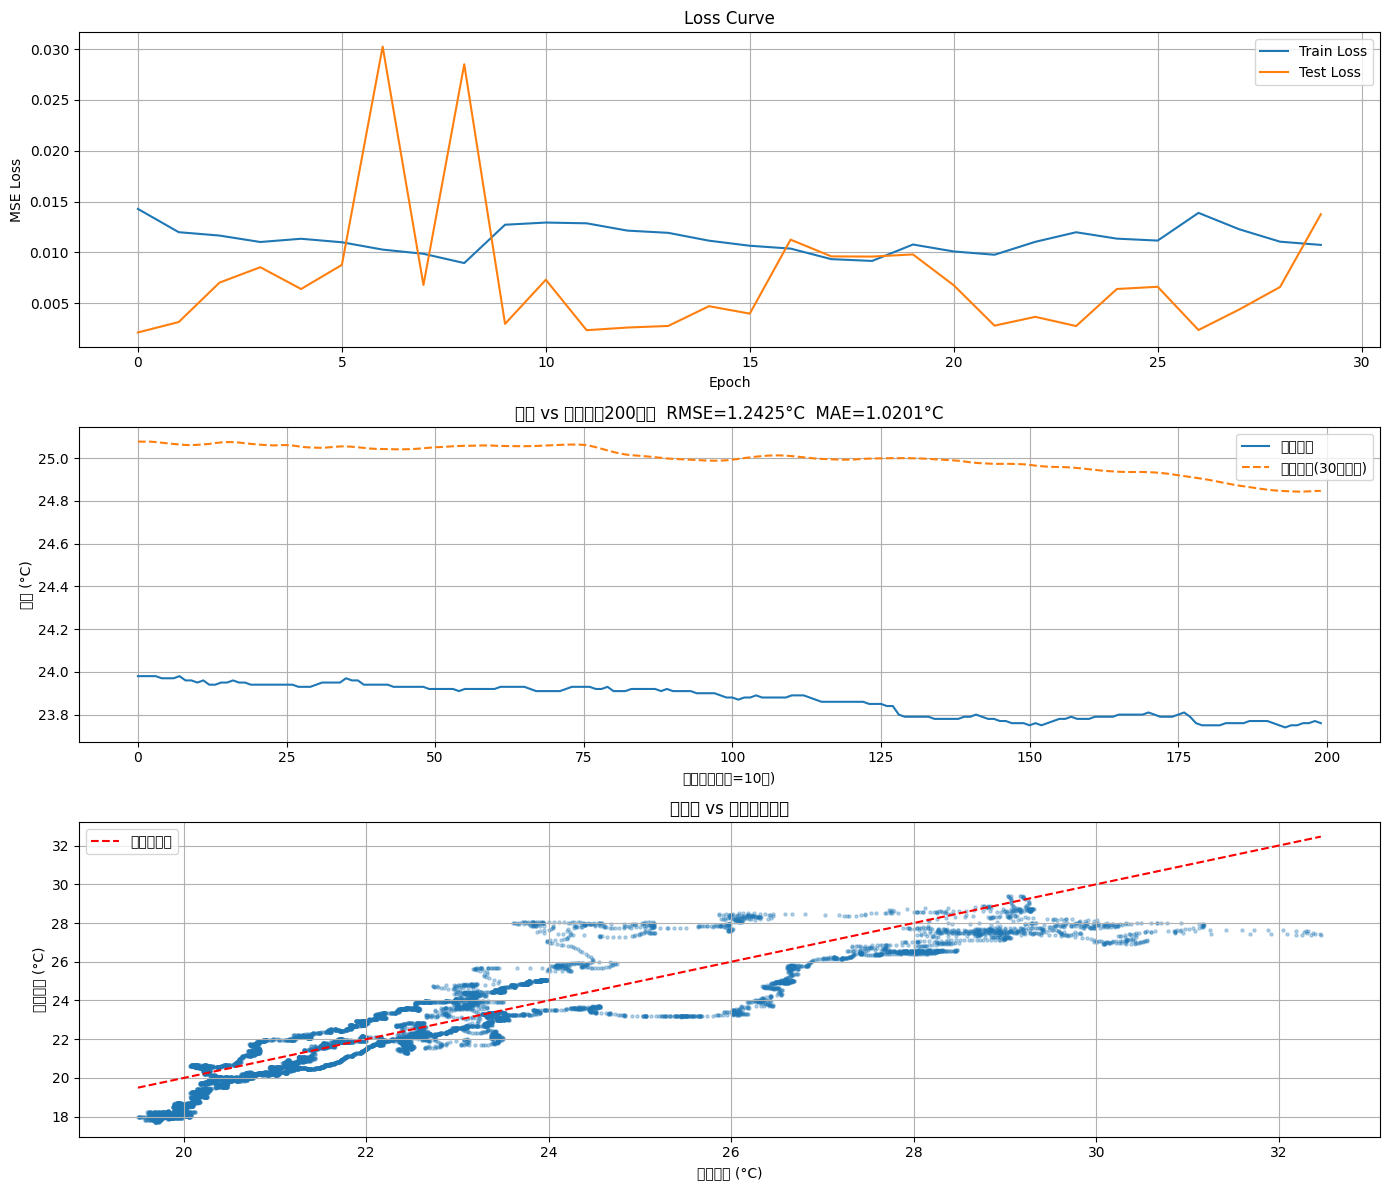

In [ ]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test.to(device)).cpu().numpy()
    y_true = y_test.numpy()

y_pred_real = y_pred * (target_max - target_min) + target_min
y_true_real = y_true * (target_max - target_min) + target_min

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 图1：Loss 曲线
axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(test_losses, label="Test Loss")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(True)

# 图2：预测 vs 真实（前200个点）
n_show = 200
axes[1].plot(y_true_real[:n_show], label="真实温度")
axes[1].plot(y_pred_real[:n_show], label="预测温度(30分钟后)", linestyle="--")
axes[1].set_title(f"预测 vs 真实（前{n_show}步）  RMSE={rmse:.4f}°C  MAE={mae:.4f}°C")
axes[1].set_xlabel("时间步（每步=10秒)")
axes[1].set_ylabel("温度 (°C)")
axes[1].legend()
axes[1].grid(True)

# 图3：散点图，完美预测应该在对角线上
axes[2].scatter(y_true_real, y_pred_real, alpha=0.3, s=5)
axes[2].plot(
    [y_true_real.min(), y_true_real.max()],
    [y_true_real.min(), y_true_real.max()],
    'r--', label="完美预测线"
)
axes[2].set_title("预测值 vs 真实值散点图")
axes[2].set_xlabel("真实温度 (°C)")
axes[2].set_ylabel("预测温度 (°C)")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig("bme280_lstm_result.png", dpi=150)
plt.show()


In [ ]:
# 前5个值对比
print("naive_real 前5:", naive_real[:5])
print("actuals/y_true 前5:", y_true_real[:5])  # LSTM用y_true_real
print("差值前5:", (naive_real - y_true_real)[:5])  # LSTM用y_true_real

NameError: name 'naive_real' is not defined